In [1]:
# ============================================
# IMPORTING REQUIRED LIBRARIES
# ============================================

# Pandas is used for handling datasets
import pandas as pd

# NumPy is used for mathematical operations
import numpy as np

# Matplotlib is used for creating graphs
import matplotlib.pyplot as plt

# Seaborn is used for better data visualization
import seaborn as sns

In [2]:
# ============================================
# LOADING THE DATASET
# ============================================

# Reading the CSV file
data = pd.read_csv("diabetes.csv")

# Displaying first 5 rows of dataset
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
# ============================================
# UNDERSTANDING THE DATASET
# ============================================

# Displaying number of rows and columns
print("Shape of dataset:", data.shape)

# Displaying column names
print("\nColumn Names:")
print(data.columns)

# Displaying dataset information
print("\nDataset Information:")
print(data.info())

Shape of dataset: (768, 9)

Column Names:
Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None


In [4]:
# ============================================
# CHECKING FOR MISSING VALUES
# ============================================

# Checking whether dataset contains null values
print(data.isnull().sum())

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [5]:
# ============================================
# DISPLAYING BASIC STATISTICS
# ============================================

# Displaying statistical summary of dataset
data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


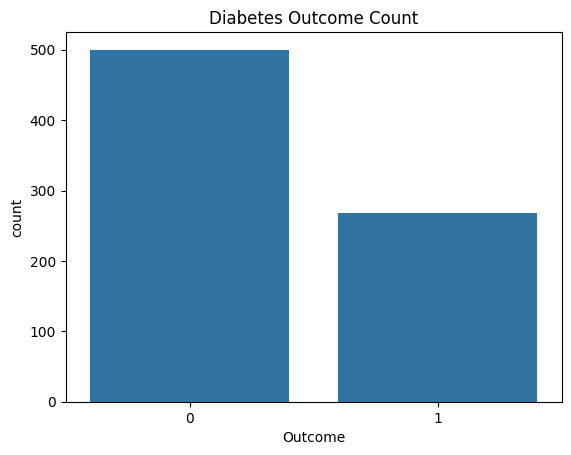

In [6]:
# ============================================
# VISUALIZING TARGET VARIABLE
# ============================================

# Counting diabetes and non-diabetes cases
sns.countplot(x='Outcome', data=data)

# Adding title
plt.title("Diabetes Outcome Count")

# Display graph
plt.show()

In [7]:
# ============================================
# FEATURE SELECTION
# ============================================

# Selecting input features
X = data.drop('Outcome', axis=1)

# Selecting target variable
y = data['Outcome']

# Displaying first 5 rows of input features
print("Input Features:")
print(X.head())

# Displaying target values
print("\nTarget Variable:")
print(y.head())

Input Features:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  
0                     0.627   50  
1                     0.351   31  
2                     0.672   32  
3                     0.167   21  
4                     2.288   33  

Target Variable:
0    1
1    0
2    1
3    0
4    1
Name: Outcome, dtype: int64


In [8]:
# ============================================
# CHECKING DUPLICATE VALUES
# ============================================

# Checking duplicate rows
print("Duplicate Rows:", data.duplicated().sum())

Duplicate Rows: 0


In [9]:
# ============================================
# CHECKING INVALID ZERO VALUES
# ============================================

# Columns where zero values are invalid
columns = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

# Counting zero values in each column
for column in columns:
    print(column, ":", (data[column] == 0).sum())

Glucose : 5
BloodPressure : 35
SkinThickness : 227
Insulin : 374
BMI : 11


In [10]:
# ============================================
# REPLACING INVALID ZERO VALUES
# ============================================

# Replacing zero values with NaN
columns = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

for column in columns:
    data[column] = data[column].replace(0, np.nan)

# Filling missing values using mean
for column in columns:
    data[column] = data[column].fillna(data[column].mean())

print("Invalid values replaced successfully")

Invalid values replaced successfully


In [11]:
# ============================================
# FEATURE SCALING
# ============================================

# Importing StandardScaler
from sklearn.preprocessing import StandardScaler

# Creating scaler object
scaler = StandardScaler()

# Scaling input features
X_scaled = scaler.fit_transform(X)

# Displaying scaled data
print(X_scaled[:5])

[[ 0.63994726  0.84832379  0.14964075  0.90726993 -0.69289057  0.20401277
   0.46849198  1.4259954 ]
 [-0.84488505 -1.12339636 -0.16054575  0.53090156 -0.69289057 -0.68442195
  -0.36506078 -0.19067191]
 [ 1.23388019  1.94372388 -0.26394125 -1.28821221 -0.69289057 -1.10325546
   0.60439732 -0.10558415]
 [-0.84488505 -0.99820778 -0.16054575  0.15453319  0.12330164 -0.49404308
  -0.92076261 -1.04154944]
 [-1.14185152  0.5040552  -1.50468724  0.90726993  0.76583594  1.4097456
   5.4849091  -0.0204964 ]]


In [12]:
X_scaled

array([[ 0.63994726,  0.84832379,  0.14964075, ...,  0.20401277,
         0.46849198,  1.4259954 ],
       [-0.84488505, -1.12339636, -0.16054575, ..., -0.68442195,
        -0.36506078, -0.19067191],
       [ 1.23388019,  1.94372388, -0.26394125, ..., -1.10325546,
         0.60439732, -0.10558415],
       ...,
       [ 0.3429808 ,  0.00330087,  0.14964075, ..., -0.73518964,
        -0.68519336, -0.27575966],
       [-0.84488505,  0.1597866 , -0.47073225, ..., -0.24020459,
        -0.37110101,  1.17073215],
       [-0.84488505, -0.8730192 ,  0.04624525, ..., -0.20212881,
        -0.47378505, -0.87137393]], shape=(768, 8))

In [13]:
# ============================================
# SPLITTING TRAINING AND TESTING DATA
# ============================================

# Importing train_test_split
from sklearn.model_selection import train_test_split

# Splitting dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Displaying shape of training and testing data
print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (614, 8)
Testing Data Shape: (154, 8)


In [15]:
# ============================================
# IMPORTING LOGISTIC REGRESSION MODEL
# ============================================

from sklearn.linear_model import LogisticRegression

# Creating Logistic Regression model
model = LogisticRegression(max_iter=1000)

# Training the model
model.fit(X_train, y_train)

print("Model trained successfully")

Model trained successfully


In [16]:
# ============================================
# MAKING PREDICTIONS
# ============================================

# Predicting test data
y_pred = model.predict(X_test)

# Displaying first 10 predictions
print("Predicted Values:")
print(y_pred[:10])

Predicted Values:
[0 0 0 0 0 0 0 1 1 1]


In [17]:
# ============================================
# COMPARING ACTUAL AND PREDICTED VALUES
# ============================================

# Creating comparison table
comparison = pd.DataFrame({
    'Actual Value': y_test.values,
    'Predicted Value': y_pred
})

# Displaying first 10 rows
comparison.head(10)

,Actual Value,Predicted Value
0,0,0
1,0,0
2,0,0
3,0,0
4,0,0
5,0,0
6,0,0
7,0,1
8,0,1
9,0,1


In [18]:
# ============================================
# CALCULATING MODEL ACCURACY
# ============================================

from sklearn.metrics import accuracy_score

# Calculating accuracy
accuracy = accuracy_score(y_test, y_pred)

# Displaying accuracy
print("Model Accuracy:", accuracy)

Model Accuracy: 0.7467532467532467


In [19]:
# ============================================
# RANDOM FOREST CLASSIFIER
# ============================================

# Importing Random Forest model
from sklearn.ensemble import RandomForestClassifier

# Creating model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Training the model
rf_model.fit(X_train, y_train)

print("Random Forest Model Trained Successfully")

Random Forest Model Trained Successfully


In [20]:
# ============================================
# RANDOM FOREST PREDICTIONS
# ============================================

# Predicting test data
rf_predictions = rf_model.predict(X_test)

# Displaying predictions
print(rf_predictions[:10])

[0 0 0 0 0 1 0 1 1 1]


In [21]:
# ============================================
# RANDOM FOREST ACCURACY
# ============================================

from sklearn.metrics import accuracy_score

# Calculating accuracy
rf_accuracy = accuracy_score(y_test, rf_predictions)

# Displaying accuracy
print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.7207792207792207


In [23]:
!pip install xgboost


In [24]:
# ============================================
# XGBOOST CLASSIFIER
# ============================================

# Importing XGBoost
from xgboost import XGBClassifier

# Creating model
xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)

# Training model
xgb_model.fit(X_train, y_train)

print("XGBoost Model Trained Successfully")

XGBoost Model Trained Successfully


In [25]:

# ============================================
# XGBOOST PREDICTIONS
# ============================================

# Predicting test data
xgb_predictions = xgb_model.predict(X_test)

print(xgb_predictions[:10])

[1 0 0 0 0 1 0 1 1 1]


In [26]:
# ============================================
# XGBOOST ACCURACY
# ============================================

from sklearn.metrics import accuracy_score

# Calculating accuracy
xgb_accuracy = accuracy_score(y_test, xgb_predictions)

print("XGBoost Accuracy:", xgb_accuracy)

XGBoost Accuracy: 0.7077922077922078


In [27]:
# ============================================
# CONFUSION MATRIX
# ============================================

from sklearn.metrics import confusion_matrix

# Creating confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Displaying confusion matrix
print(cm)

[[78 21]
 [18 37]]


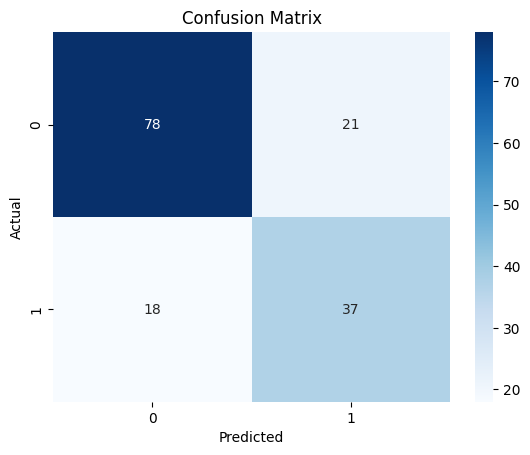

In [28]:
# ============================================
# VISUALIZING CONFUSION MATRIX
# ============================================

# Creating heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

# Adding labels and title
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

# Display graph
plt.show()

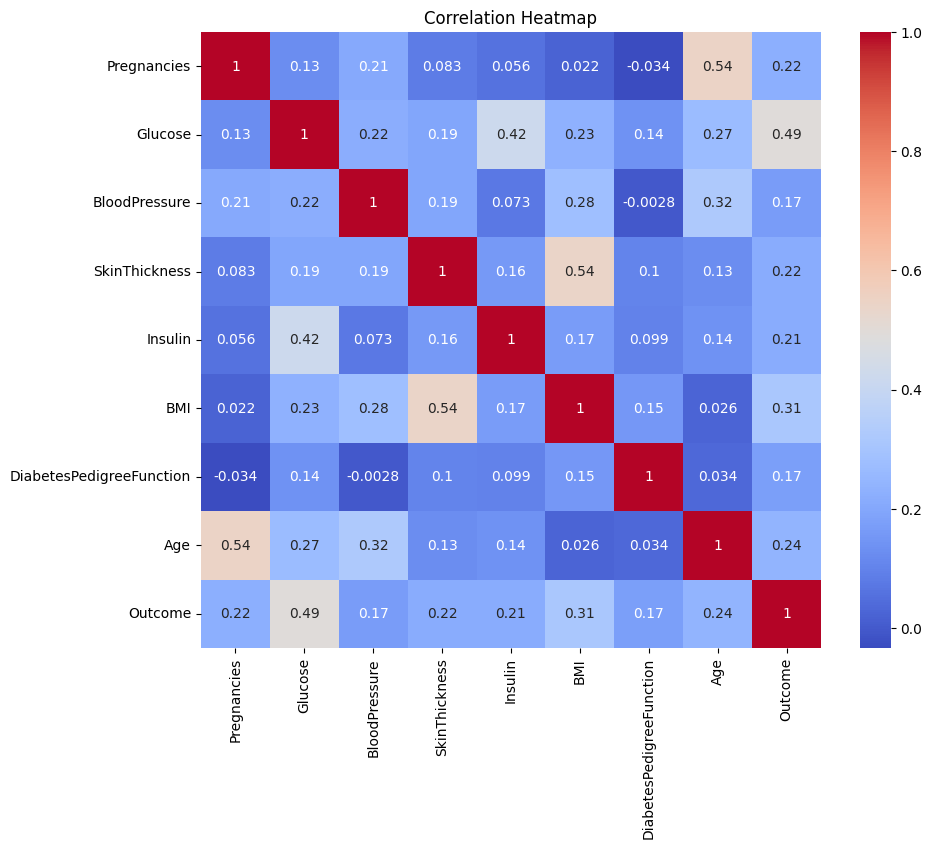

In [29]:
# ============================================
# CORRELATION HEATMAP
# ============================================

# Creating correlation matrix
correlation = data.corr()

# Setting figure size
plt.figure(figsize=(10, 8))

# Creating heatmap
sns.heatmap(correlation, annot=True, cmap='coolwarm')

# Adding title
plt.title("Correlation Heatmap")

# Display graph
plt.show()

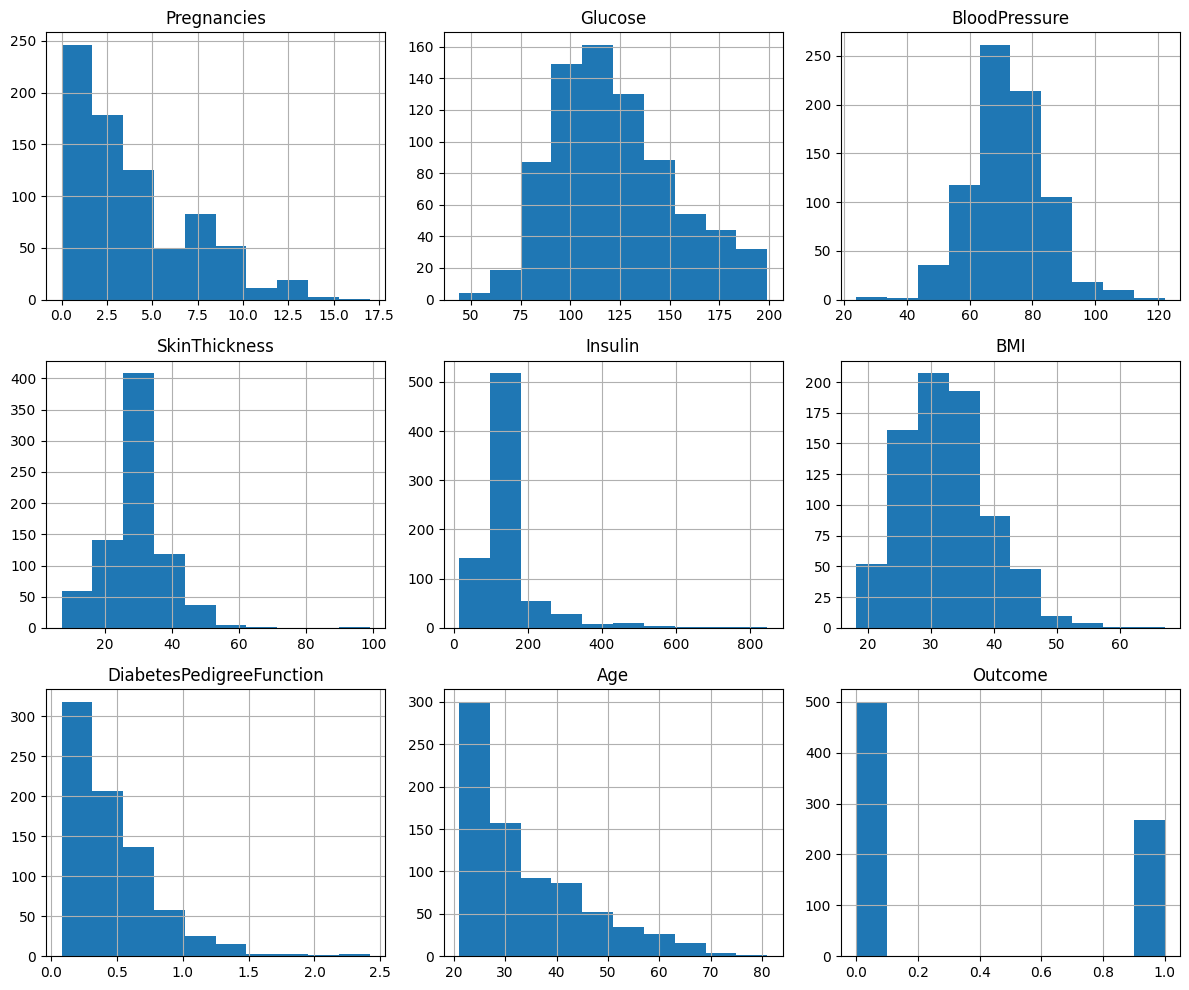

In [30]:
# ============================================
# HISTOGRAMS
# ============================================

# Creating histograms for all columns
data.hist(figsize=(12, 10))

# Adjusting layout
plt.tight_layout()

# Display graphs
plt.show()

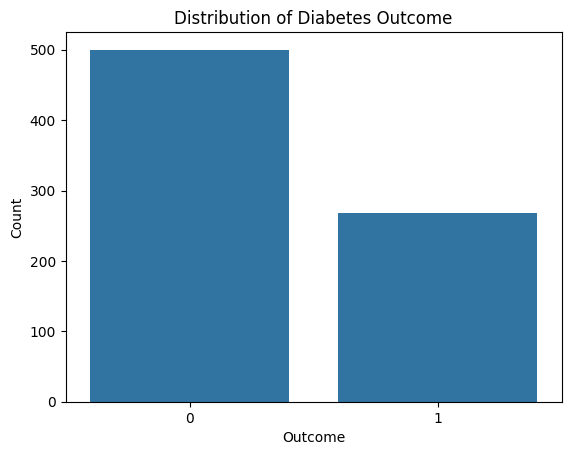

In [31]:
# ============================================
# DIABETES OUTCOME DISTRIBUTION
# ============================================

# Creating countplot
sns.countplot(x='Outcome', data=data)

# Adding labels and title
plt.title("Distribution of Diabetes Outcome")
plt.xlabel("Outcome")
plt.ylabel("Count")

# Display graph
plt.show()

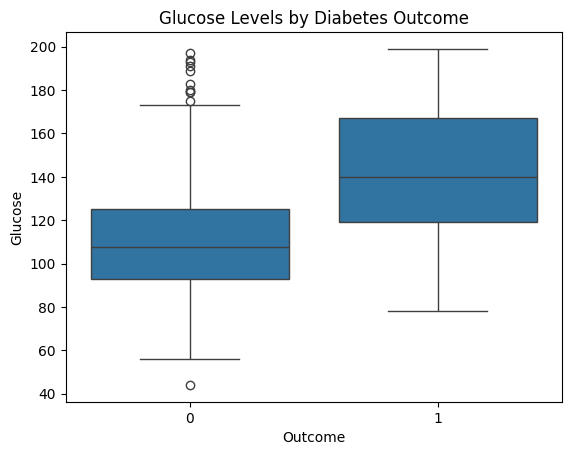

In [32]:
# ============================================
# GLUCOSE VS OUTCOME
# ============================================

# Creating boxplot
sns.boxplot(x='Outcome', y='Glucose', data=data)

# Adding title
plt.title("Glucose Levels by Diabetes Outcome")

# Display graph
plt.show()

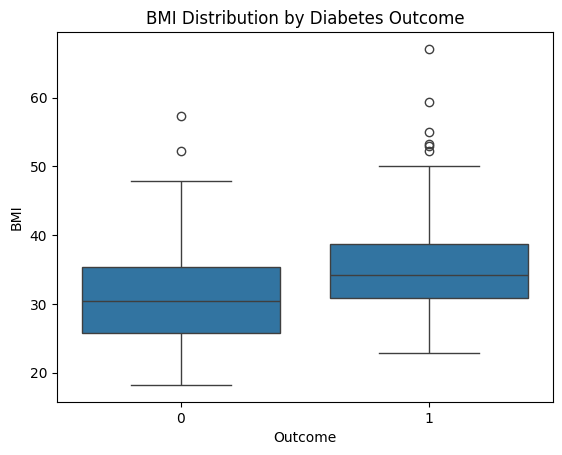

In [33]:
# ============================================
# BMI VS OUTCOME
# ============================================

# Creating boxplot
sns.boxplot(x='Outcome', y='BMI', data=data)

# Adding title
plt.title("BMI Distribution by Diabetes Outcome")

# Display graph
plt.show()

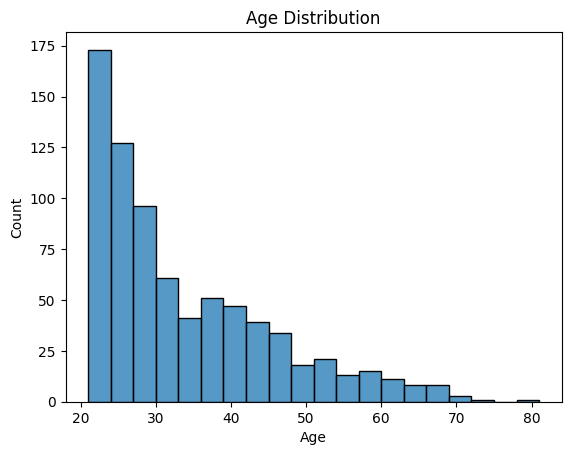

In [34]:
# ============================================
# AGE DISTRIBUTION
# ============================================

# Creating age distribution plot
sns.histplot(data['Age'], bins=20)

# Adding title
plt.title("Age Distribution")

# Display graph
plt.show()

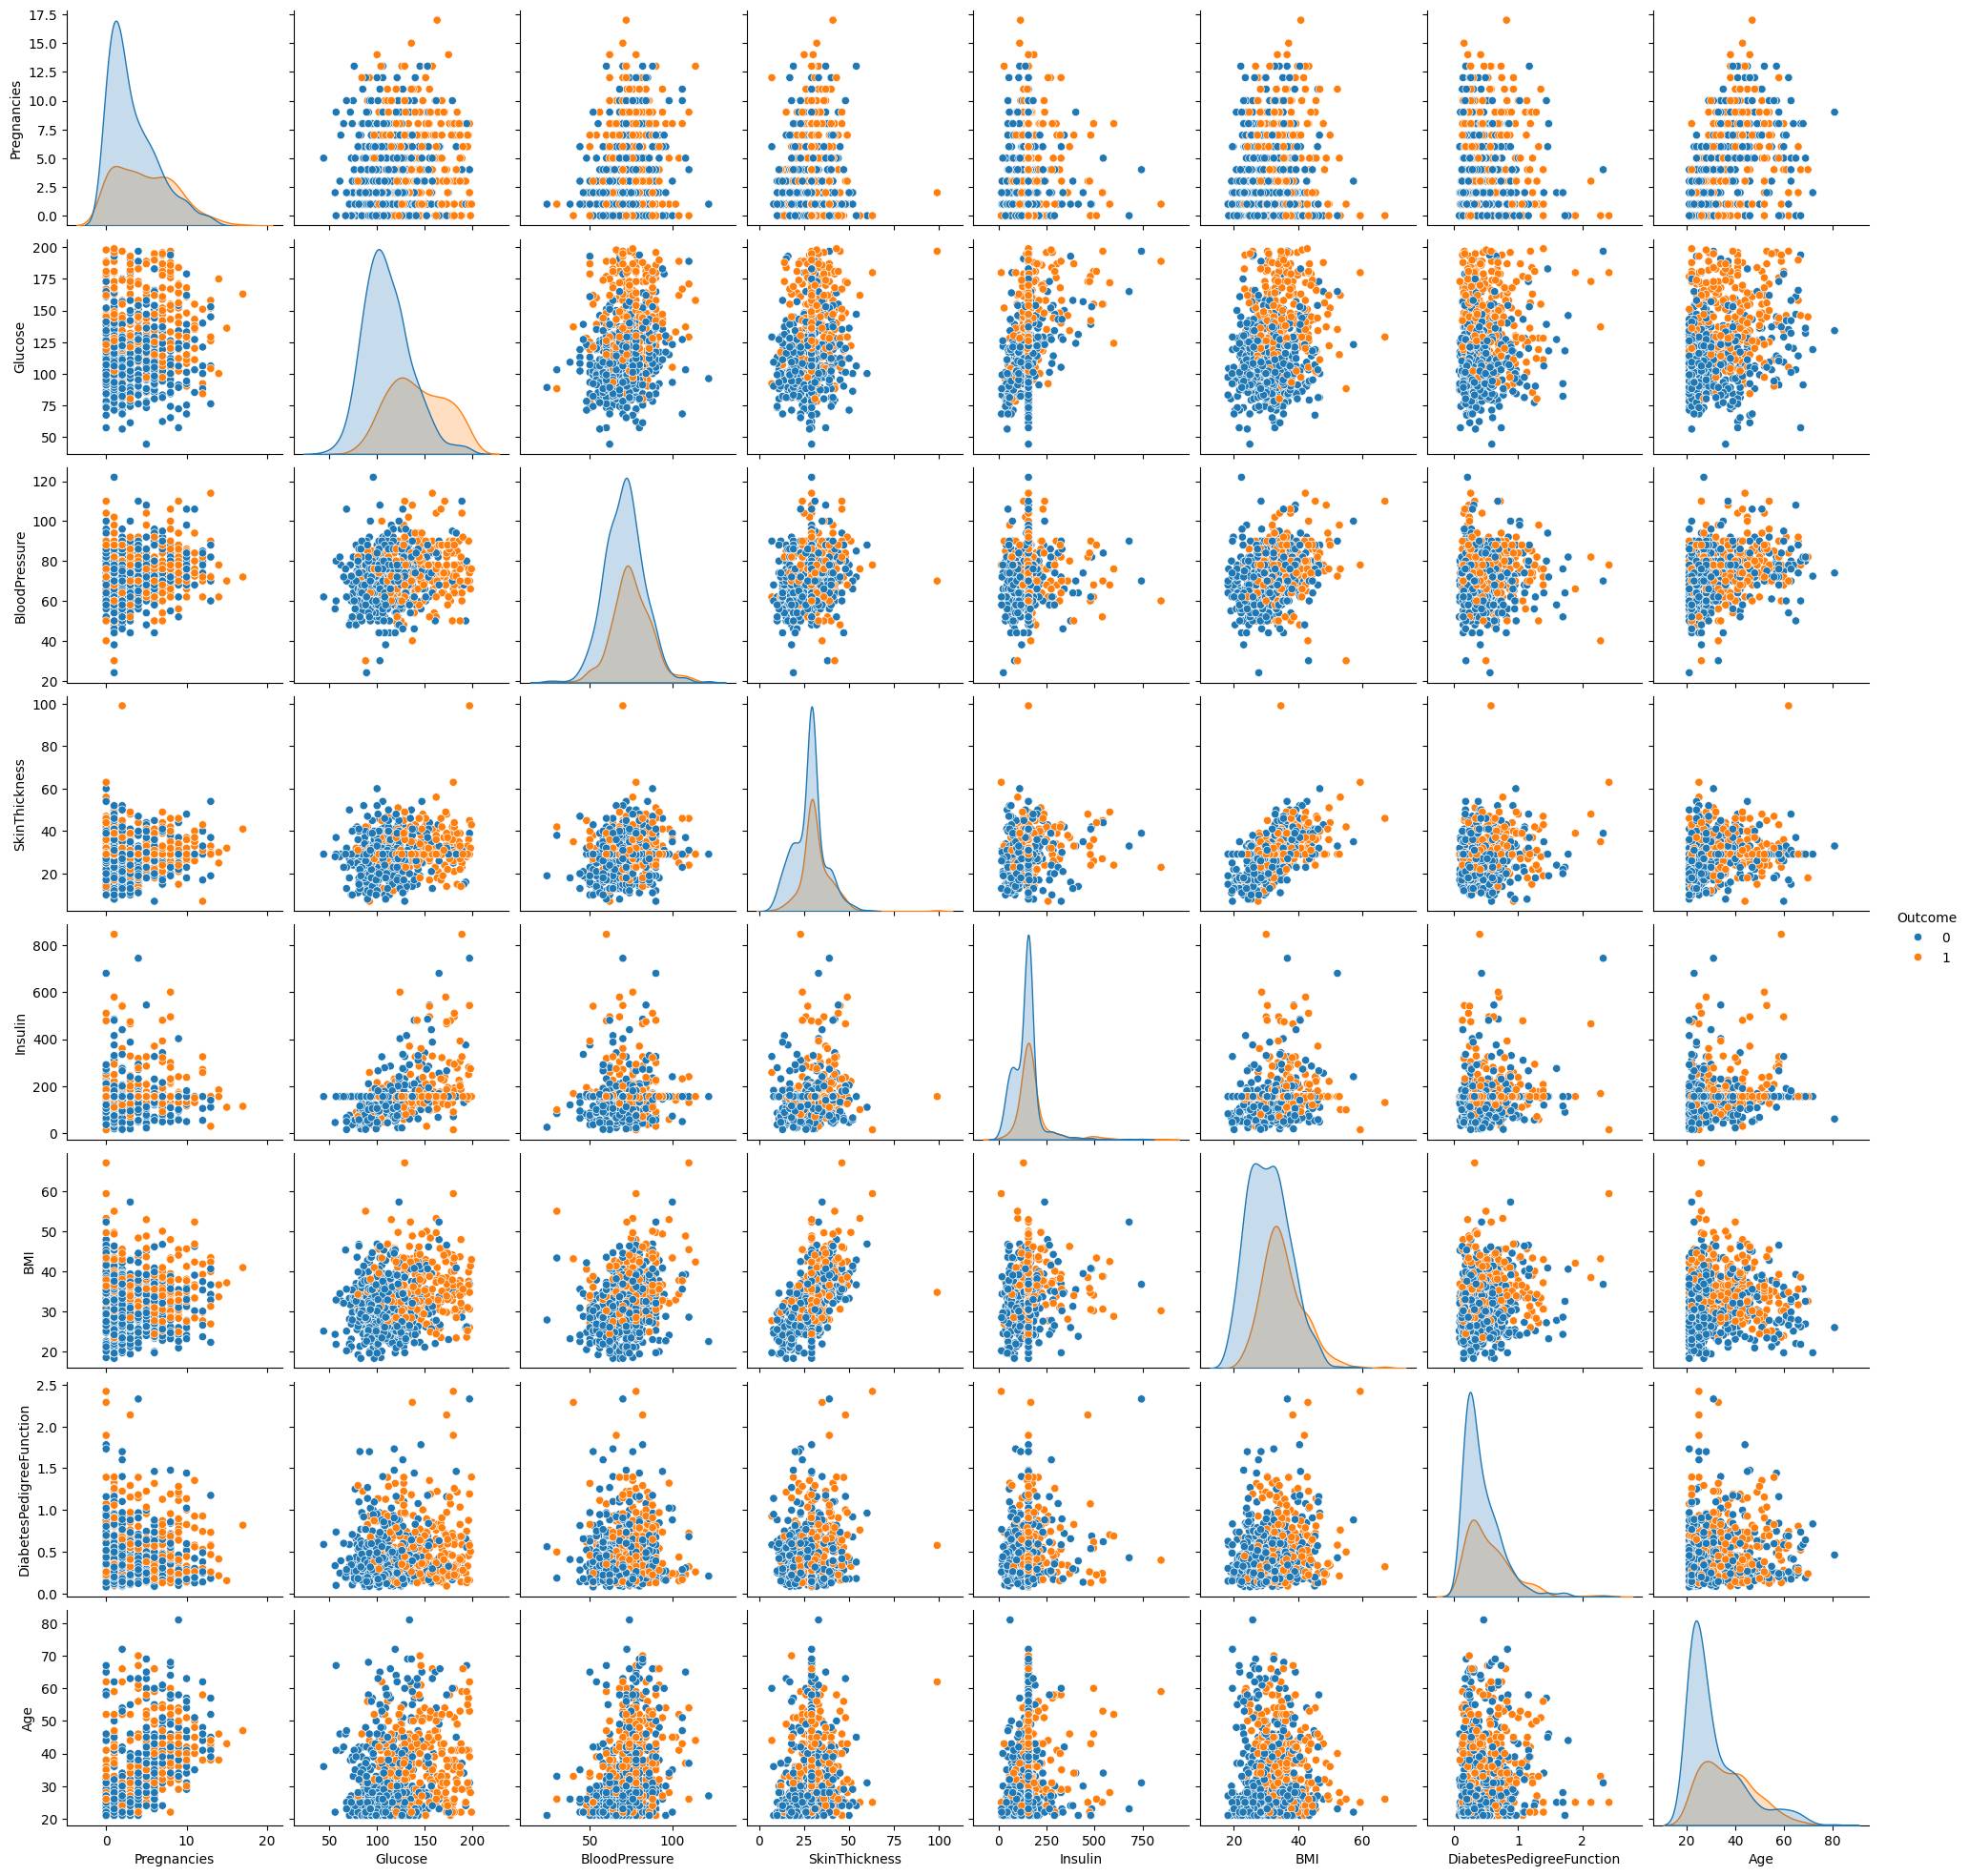

In [37]:
# ============================================
# PAIRPLOT VISUALIZATION
# ============================================

# Creating pairplot
sns.pairplot(data, hue='Outcome')

# Display graph
plt.show()

In [38]:
# ============================================
# FEATURE IMPORTANCE
# ============================================

# Getting feature importance
importance = rf_model.feature_importances_

# Creating dataframe
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})

# Sorting values
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

# Displaying results
print(feature_importance)

                    Feature  Importance
1                   Glucose    0.258864
5                       BMI    0.169984
7                       Age    0.140931
6  DiabetesPedigreeFunction    0.123768
2             BloodPressure    0.088134
0               Pregnancies    0.076551
4                   Insulin    0.076122
3             SkinThickness    0.065646
